# Tuned Hybrid LSTM-Transformer

This notebook improves the **best-performing light Hybrid LSTM-Transformer** 


## Improvements in this version
- keep the best **light Hybrid backbone**
- add auxiliary **turn / no-turn** head
- use **turn-weighted MSE** for heading prediction
- use a slightly lower learning rate for more stable optimization

In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import math
import matplotlib.pyplot as plt
import time
import os
import random
import h5py

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

BATCH_SIZE = 256
NUM_EPOCHS = 18
LEARNING_RATE = 5e-4
NUM_WORKERS = 0
WINDOW_SIZE = 200
STRIDE = 50
SAMPLING_RATE = 200
TEST_ROOT = "unseen_subjects_test_set"

TURN_THRESHOLD_DEG = 25.0
TURN_LOSS_WEIGHT = 0.15
TURN_SAMPLE_UPWEIGHT = 1.25

Using device: cpu


In [3]:
X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")
X_val = np.load("X_val.npy")
y_val = np.load("y_val.npy")
X_test = np.load("X_test.npy")
y_test = np.load("y_test.npy")

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:", X_val.shape, "y_val:", y_val.shape)
print("X_test:", X_test.shape, "y_test:", y_test.shape)

X_train: (198036, 200, 9) y_train: (198036, 2)
X_val: (82656, 200, 9) y_val: (82656, 2)
X_test: (76894, 200, 9) y_test: (76894, 2)


In [25]:
def sincos_to_angle_deg_np(arr):
    ang = np.degrees(np.arctan2(arr[:, 0], arr[:, 1]))
    return (ang + 360) % 360

def circular_error_deg_np(pred_deg, true_deg):
    diff = np.abs(pred_deg - true_deg)
    return np.minimum(diff, 360 - diff)

def build_turn_labels_from_targets(y_sincos, threshold_deg=25.0):
    heading_deg = sincos_to_angle_deg_np(y_sincos)
    turn_mag = np.zeros_like(heading_deg)
    turn_mag[1:] = circular_error_deg_np(heading_deg[1:], heading_deg[:-1])
    turn_label = (turn_mag >= threshold_deg).astype(np.float32)
    return turn_label.reshape(-1, 1), turn_mag

turn_train, _ = build_turn_labels_from_targets(y_train, TURN_THRESHOLD_DEG)
turn_val, _ = build_turn_labels_from_targets(y_val, TURN_THRESHOLD_DEG)
turn_test, _ = build_turn_labels_from_targets(y_test, TURN_THRESHOLD_DEG)



In [26]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
turn_train_t = torch.tensor(turn_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
turn_val_t = torch.tensor(turn_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)
turn_test_t = torch.tensor(turn_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t, turn_train_t), batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t, turn_val_t), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t, turn_test_t), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

In [28]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class TunedLightHybridLSTMTransformer(nn.Module):
    def __init__(self, input_dim=9, lstm_hidden=64, lstm_layers=2, transformer_dim=64,
                 num_heads=4, transformer_layers=2, ff_dim=128, lstm_dropout=0.25,
                 transformer_dropout=0.15, fc_hidden=64, output_dim=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=lstm_hidden, num_layers=lstm_layers,
                            batch_first=True, dropout=lstm_dropout if lstm_layers > 1 else 0.0)
        self.proj = nn.Linear(lstm_hidden, transformer_dim)
        self.pos_encoder = PositionalEncoding(transformer_dim, max_len=200)
        enc_layer = nn.TransformerEncoderLayer(d_model=transformer_dim, nhead=num_heads,
                                               dim_feedforward=ff_dim, dropout=transformer_dropout,
                                               batch_first=True, activation="relu")
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=transformer_layers)
        self.heading_head = nn.Sequential(
            nn.Linear(lstm_hidden + transformer_dim, fc_hidden),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(fc_hidden, output_dim)
        )
        self.turn_head = nn.Sequential(
            nn.Linear(lstm_hidden + transformer_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        lstm_out, (h_n, _) = self.lstm(x)
        lstm_last = h_n[-1]
        trans_in = self.pos_encoder(self.proj(lstm_out))
        trans_out = self.transformer(trans_in)
        trans_pool = trans_out.mean(dim=1)
        fused = torch.cat([lstm_last, trans_pool], dim=1)
        return self.heading_head(fused), self.turn_head(fused)

In [29]:
model = TunedLightHybridLSTMTransformer().to(device)
turn_criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3, min_lr=1e-6)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", total_params)

heading_mse = nn.MSELoss(reduction="none")

def weighted_heading_mse(pred, target, turn_labels, upweight=1.25):
    per_sample = heading_mse(pred, target).mean(dim=1, keepdim=True)
    weights = 1.0 + (upweight - 1.0) * turn_labels
    return (weights * per_sample).mean()

Trainable parameters: 136131


## Train the tuned model

In [8]:
best_val_loss = float("inf")
early_stop_counter = 0
early_stop_patience = 7

train_losses, val_losses, train_epoch_times, val_epoch_times, lr_history = [], [], [], [], []
checkpoint_path = "best_light_hybrid_tuned_turn_aware_mse.pth"

training_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()
    model.train()
    running_train_loss = 0.0

    for xb, yb, tb in train_loader:
        xb, yb, tb = xb.to(device), yb.to(device), tb.to(device)
        optimizer.zero_grad()
        heading_pred, turn_logit = model(xb)
        heading_loss = weighted_heading_mse(heading_pred, yb, tb, upweight=TURN_SAMPLE_UPWEIGHT)
        turn_loss = turn_criterion(turn_logit, tb)
        loss = heading_loss + TURN_LOSS_WEIGHT * turn_loss
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * xb.size(0)

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)
    train_time = time.time() - epoch_start_time
    train_epoch_times.append(train_time)

    model.eval()
    running_val_loss = 0.0
    val_start_time = time.time()

    with torch.no_grad():
        for xb, yb, tb in val_loader:
            xb, yb, tb = xb.to(device), yb.to(device), tb.to(device)
            heading_pred, turn_logit = model(xb)
            heading_loss = weighted_heading_mse(heading_pred, yb, tb, upweight=TURN_SAMPLE_UPWEIGHT)
            turn_loss = turn_criterion(turn_logit, tb)
            loss = heading_loss + TURN_LOSS_WEIGHT * turn_loss
            running_val_loss += loss.item() * xb.size(0)

    val_time = time.time() - val_start_time
    val_epoch_times.append(val_time)
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    scheduler.step(epoch_val_loss)
    current_lr = optimizer.param_groups[0]["lr"]
    lr_history.append(current_lr)

    print(f"Epoch {epoch+1:02d} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f} | Train Time: {train_time:.2f}s | Val Time: {val_time:.2f}s | LR: {current_lr:.6f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        early_stop_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
    else:
        early_stop_counter += 1
        if early_stop_counter >= early_stop_patience:
            print("Early stopping triggered.")
            break

total_training_time = time.time() - training_start_time
avg_val_time = np.mean(val_epoch_times)

print(f"\nTotal training time: {total_training_time:.2f} seconds")
print(f"Average validation time per epoch: {avg_val_time:.2f} seconds")
print("Best checkpoint saved to:", checkpoint_path)

Epoch 01 | Train Loss: 0.541046 | Val Loss: 0.518823 | Train Time: 1244.72s | Val Time: 100.08s | LR: 0.000500
Epoch 02 | Train Loss: 0.487064 | Val Loss: 0.487686 | Train Time: 1178.05s | Val Time: 103.58s | LR: 0.000500
Epoch 03 | Train Loss: 0.447449 | Val Loss: 0.464580 | Train Time: 1282.88s | Val Time: 111.35s | LR: 0.000500
Epoch 04 | Train Loss: 0.417136 | Val Loss: 0.450632 | Train Time: 1201.85s | Val Time: 109.75s | LR: 0.000500
Epoch 05 | Train Loss: 0.397663 | Val Loss: 0.455032 | Train Time: 1208.91s | Val Time: 112.74s | LR: 0.000500
Epoch 06 | Train Loss: 0.382723 | Val Loss: 0.443722 | Train Time: 1168.97s | Val Time: 102.06s | LR: 0.000500
Epoch 07 | Train Loss: 0.371684 | Val Loss: 0.442213 | Train Time: 1191.12s | Val Time: 100.49s | LR: 0.000500
Epoch 08 | Train Loss: 0.362936 | Val Loss: 0.444053 | Train Time: 1186.20s | Val Time: 97.79s | LR: 0.000500
Epoch 09 | Train Loss: 0.356583 | Val Loss: 0.445885 | Train Time: 1171.48s | Val Time: 103.10s | LR: 0.000500
Ep

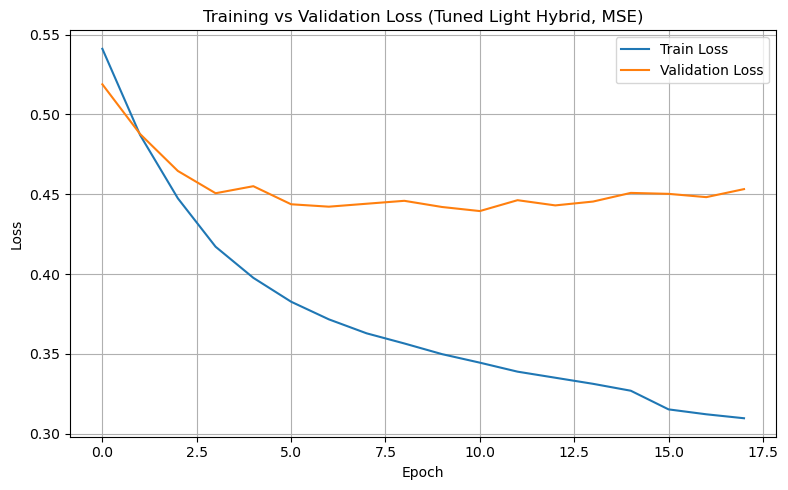

In [30]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (Tuned Light Hybrid, MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("loss_curve_tuned_best_model_mse.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
def sincos_to_angle_deg(arr):
    angles = np.degrees(np.arctan2(arr[:, 0], arr[:, 1]))
    return (angles + 360) % 360

def circular_error_deg(pred_deg, true_deg):
    diff = np.abs(pred_deg - true_deg)
    return np.minimum(diff, 360 - diff)

def circular_mae_rmse(pred_deg, true_deg):
    err = circular_error_deg(pred_deg, true_deg)
    return np.mean(err), np.sqrt(np.mean(err ** 2))

## Final test evaluation

In [32]:
model = TunedLightHybridLSTMTransformer().to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

all_heading_preds, all_heading_targets, all_turn_logits, all_turn_targets = [], [], [], []
test_start_time = time.time()

with torch.no_grad():
    for xb, yb, tb in test_loader:
        xb = xb.to(device)
        heading_pred, turn_logit = model(xb)
        all_heading_preds.append(heading_pred.cpu().numpy())
        all_heading_targets.append(yb.numpy())
        all_turn_logits.append(turn_logit.cpu().numpy())
        all_turn_targets.append(tb.numpy())

test_time = time.time() - test_start_time

all_heading_preds = np.concatenate(all_heading_preds, axis=0)
all_heading_targets = np.concatenate(all_heading_targets, axis=0)
all_turn_logits = np.concatenate(all_turn_logits, axis=0)
all_turn_targets = np.concatenate(all_turn_targets, axis=0)

pred_deg = sincos_to_angle_deg(all_heading_preds)
true_deg = sincos_to_angle_deg(all_heading_targets)
mae, rmse = circular_mae_rmse(pred_deg, true_deg)

turn_probs = 1.0 / (1.0 + np.exp(-all_turn_logits))
turn_pred = (turn_probs >= 0.5).astype(np.float32)
turn_acc = (turn_pred == all_turn_targets).mean()

print(f"Test MAE:  {mae:.4f} degrees")
print(f"Test RMSE: {rmse:.4f} degrees")
print(f"Test time: {test_time:.2f} seconds")
print(f"Turn classification accuracy: {turn_acc:.4f}")

Test MAE:  66.7692 degrees
Test RMSE: 83.5339 degrees
Test time: 85.03 seconds
Turn classification accuracy: 0.8349


## Full single unseen test trajectory plot

In [16]:
def create_windows(X, y, window_size=200, stride=50):
    X_windows, y_windows = [], []
    for start in range(0, len(X) - window_size, stride):
        end = start + window_size
        X_windows.append(X[start:end])
        y_windows.append(y[end - 1])
    return np.array(X_windows), np.array(y_windows)

def load_sequence(seq_path):
    with h5py.File(seq_path, "r") as f:
        acce = f["synced"]["acce"][:]
        gyro = f["synced"]["gyro"][:]
        magnet = f["synced"]["magnet"][:]
        tango_pos = f["pose"]["tango_pos"][:]
    dx = np.diff(tango_pos[:, 0]); dy = np.diff(tango_pos[:, 1])
    heading = np.arctan2(dy, dx)
    X = np.concatenate([acce[1:], gyro[1:], magnet[1:]], axis=1)
    y = np.column_stack([np.sin(heading), np.cos(heading)])
    return X, y

def sincos_to_deg(arr):
    deg = np.degrees(np.arctan2(arr[:, 0], arr[:, 1]))
    return (deg + 360) % 360

In [21]:
seq_name = sorted(os.listdir(TEST_ROOT))[9]
seq_path = os.path.join(TEST_ROOT, seq_name, "data.hdf5")
print("Using full test trajectory:", seq_name)

X_seq_raw, y_seq_raw = load_sequence(seq_path)
X_seq_win, y_seq_win = create_windows(X_seq_raw, y_seq_raw, WINDOW_SIZE, STRIDE)

mean = np.load("mean.npy")
std = np.load("std.npy")
X_seq_win = (X_seq_win - mean) / std

X_seq_t = torch.tensor(X_seq_win, dtype=torch.float32)
seq_loader = DataLoader(TensorDataset(X_seq_t), batch_size=BATCH_SIZE, shuffle=False)

seq_preds = []
model.eval()
with torch.no_grad():
    for (xb,) in seq_loader:
        xb = xb.to(device)
        heading_out, _ = model(xb)
        seq_preds.append(heading_out.cpu().numpy())

seq_preds = np.concatenate(seq_preds, axis=0)
pred_deg_seq = sincos_to_deg(seq_preds)
true_deg_seq = sincos_to_deg(y_seq_win)
time_sec = (np.arange(len(pred_deg_seq)) * STRIDE + (WINDOW_SIZE - 1)) / SAMPLING_RATE

print("Number of windows in this full trajectory:", len(pred_deg_seq))

Using full test trajectory: a042_2
Number of windows in this full trajectory: 2937


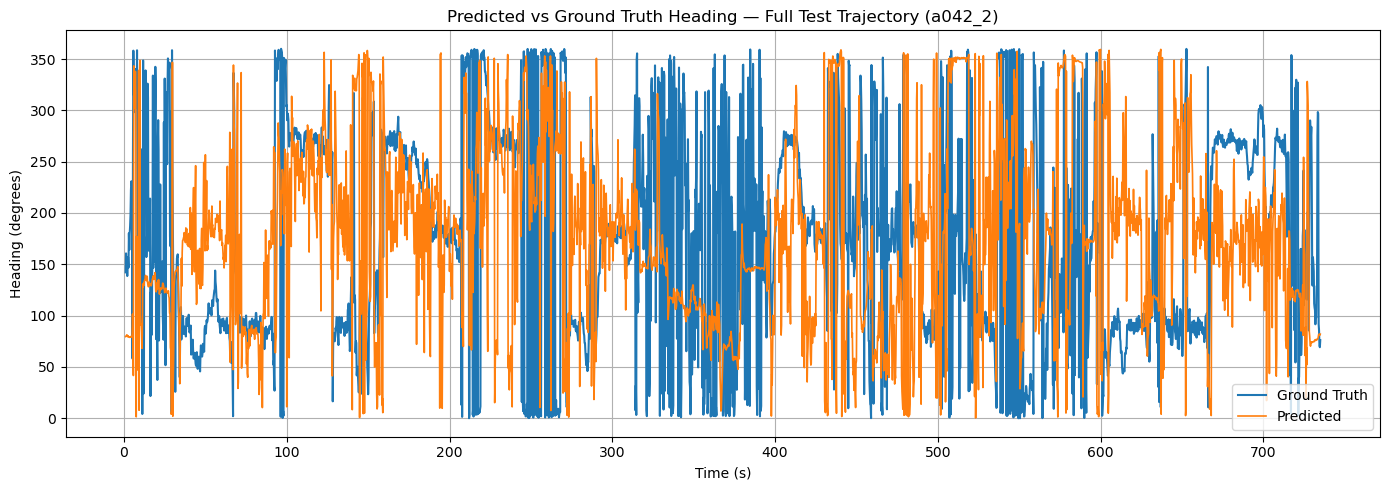

In [22]:
plt.figure(figsize=(14,5))
plt.plot(time_sec, true_deg_seq, label="Ground Truth", linewidth=1.5)
plt.plot(time_sec, pred_deg_seq, label="Predicted", linewidth=1.2)
plt.xlabel("Time (s)")
plt.ylabel("Heading (degrees)")
plt.title(f"Predicted vs Ground Truth Heading — Full Test Trajectory ({seq_name})")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("pred_vs_true_full_trajectory_tuned_best_model_mse.png", dpi=300, bbox_inches="tight")
plt.show()

## Scenario-wise MAE

In [23]:
seq_names = sorted([d for d in os.listdir(TEST_ROOT) if os.path.isdir(os.path.join(TEST_ROOT, d))])
seq_lengths = {}
for seq_name in seq_names:
    seq_path = os.path.join(TEST_ROOT, seq_name, "data.hdf5")
    X_seq_raw, y_seq_raw = load_sequence(seq_path)
    X_seq_win, y_seq_win = create_windows(X_seq_raw, y_seq_raw, WINDOW_SIZE, STRIDE)
    seq_lengths[seq_name] = len(X_seq_win)

median_len = np.median(list(seq_lengths.values()))
print("Median trajectory length in windows:", median_len)

Median trajectory length in windows: 2551.5


In [24]:
mean = np.load("mean.npy")
std = np.load("std.npy")
straight_errors, sharp_errors, short_traj_errors, long_traj_errors = [], [], [], []

for seq_name in seq_names:
    seq_path = os.path.join(TEST_ROOT, seq_name, "data.hdf5")
    X_seq_raw, y_seq_raw = load_sequence(seq_path)
    X_seq_win, y_seq_win = create_windows(X_seq_raw, y_seq_raw, WINDOW_SIZE, STRIDE)
    X_seq_win = (X_seq_win - mean) / std

    X_seq_t = torch.tensor(X_seq_win, dtype=torch.float32)
    seq_loader = DataLoader(TensorDataset(X_seq_t), batch_size=BATCH_SIZE, shuffle=False)

    seq_preds = []
    model.eval()
    with torch.no_grad():
        for (xb,) in seq_loader:
            xb = xb.to(device)
            heading_out, _ = model(xb)
            seq_preds.append(heading_out.cpu().numpy())

    seq_preds = np.concatenate(seq_preds, axis=0)
    pred_deg = sincos_to_deg(seq_preds)
    true_deg = sincos_to_deg(y_seq_win)
    err = circular_error_deg(pred_deg, true_deg)

    turn_amount = np.zeros_like(true_deg)
    turn_amount[1:] = circular_error_deg(true_deg[1:], true_deg[:-1])

    straight_mask = turn_amount <= 10.0
    sharp_mask = turn_amount >= 45.0
    is_short = len(X_seq_win) < median_len
    is_long = len(X_seq_win) >= median_len

    if np.any(straight_mask): straight_errors.extend(err[straight_mask])
    if np.any(sharp_mask): sharp_errors.extend(err[sharp_mask])
    if is_short: short_traj_errors.extend(err)
    if is_long: long_traj_errors.extend(err)

def safe_mae(x): return float(np.mean(x)) if len(x) > 0 else np.nan

print(f"Straight walking MAE: {safe_mae(straight_errors):.4f} degrees")
print(f"Sharp turns MAE: {safe_mae(sharp_errors):.4f} degrees")
print(f"Short trajectories MAE: {safe_mae(short_traj_errors):.4f} degrees")
print(f"Long trajectories MAE: {safe_mae(long_traj_errors):.4f} degrees")

Straight walking MAE: 60.0392 degrees
Sharp turns MAE: 88.5406 degrees
Short trajectories MAE: 63.6728 degrees
Long trajectories MAE: 68.8338 degrees
